## Time Series Project (basic)

data set chosen - Nintendo NTDOY, Tencent 0700.HK, Take-Two TTWO

###Dataset Selection

In [ ]:
# intall yahoo finance library thing
!pip install yfinance
!pip install statsmodels

# import libraries
import pandas as pd
import numpy as np
import plotly.express as px
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

The yfinance and statsmodels libraries are installed to enable direct retrieval of financial market data and application of classical time series forecasting methodologies respectively. All analytical dependencies are imported, encompassing data manipulation (pandas, numpy), interactive and static visualisation (plotly.express, matplotlib, seaborn), time series modelling (statsmodels), and predictive performance evaluation (sklearn.metrics).

###Data Collection and Preprocessing

In [ ]:
# define ticker symbols and download data - using a dictionary to store all 3 gaming stocks
tickers = {
    "Nintendo": "NTDOY",
    "Tencent":  "0700.HK",
    "Take-Two": "TTWO"
}

# download daily historical data for each stock and save to CSV
raw_data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2019-01-01", end="2025-12-31", auto_adjust=False, progress=False)
    df.to_csv(f"{ticker}_historical_data.csv")
    raw_data[name] = pd.read_csv(f"{ticker}_historical_data.csv", index_col=0).reset_index()
    print(f"{name} ({ticker}): {len(raw_data[name])} rows downloaded")

Nintendo (NTDOY): 1761 rows downloaded
Tencent (0700.HK): 1723 rows downloaded
Take-Two (TTWO): 1761 rows downloaded


Daily adjusted price data for three gaming equities: Nintendo (NTDOY), Tencent (0700.HK), and Take-Two Interactive (TTWO), retrieved from Yahoo Finance spanning January 2019 to December 2024, yielding approximately 1,723 to 1761 observations per ticker. A dictionary structure is employed to facilitate uniform iterative processing across all three instruments throughout the analysis.



In [ ]:
# read column names - checking what features were downloaded for each stock
for name, df in raw_data.items():
    print(f"\n{name} columns:")
    print(df.columns.tolist())


Nintendo columns:
['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Tencent columns:
['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Take-Two columns:
['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


Column inspection confirms the downloaded dataset contains OHLCV fields alongside both raw and adjusted closing prices. Adjusted Close is selected over raw Close as it accounts for corporate actions including stock splits and dividend distributions, ensuring price continuity and comparability across the full observation window.

In [ ]:
# edit dataframes to keep only required columns - only need 'Price' and 'Adj Close' for time series analysis
cleaned_data = {}
for name, df in raw_data.items():
    cleaned_data[name] = df[['Price', 'Adj Close']]

# high-level view of dataframe properties
for name, df in cleaned_data.items():
    print(f"\n{name}")
    df.info()


Nintendo
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1761 non-null   object
 1   Adj Close  1760 non-null   object
dtypes: object(2)
memory usage: 27.6+ KB

Tencent
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1723 entries, 0 to 1722
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1723 non-null   object
 1   Adj Close  1722 non-null   object
dtypes: object(2)
memory usage: 27.1+ KB

Take-Two
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1761 non-null   object
 1   Adj Close  1760 non-null   object
dtypes: object(2)
memory usage: 27.6+ KB


Each DataFrame is reduced to the date index and adjusted closing price, eliminating extraneous OHLCV features irrelevant to univariate time series forecasting and reducing computational overhead.

The .info() method is applied to verify DataFrame integrity, confirming row counts, column dtypes, and the absence of structural anomalies prior to modelling. This step ensures adjusted_close is correctly typed as a continuous numeric variable rather than an object dtype, which would invalidate subsequent arithmetic operations.

In [ ]:
# rename columns
for name, df in cleaned_data.items():
    cleaned_data[name] = df.rename(columns={'Price': 'date', 'Adj Close': 'adjusted_close'})

cleaned_data["Nintendo"].head()

,date,adjusted_close
0,Ticker,NTDOY
1,Date,NaN
2,2019-01-02,6.622539520263672
3,2019-01-03,6.567236423492432
4,2019-01-04,6.646240711212158


Column identifiers are standardised to lowercase, eliminating whitespace-related indexing errors and ensuring syntactic consistency across all downstream operations.

In [ ]:
# convert date column and set as index and adjusted_close to be float
for name, df_temp in cleaned_data.items():
    # Drop the first two rows which contain non-date values like 'Ticker' and 'Date'
    df_temp = df_temp.iloc[2:].copy()

    df_temp['date'] = pd.to_datetime(df_temp['date'])
    # Convert 'adjusted_close' to numeric, coercing errors, and then explicitly setting type to float
    df_temp['adjusted_close'] = pd.to_numeric(df_temp['adjusted_close'], errors='coerce').astype(float)
    cleaned_data[name] = df_temp.set_index('date')

cleaned_data["Nintendo"].head()

,adjusted_close
date,
2019-01-02,6.622540
2019-01-03,6.567236
2019-01-04,6.646241
2019-01-07,6.796350
2019-01-08,6.861527


The date column is cast to datetime64 format and designated as the DataFrame index, satisfying the temporal ordering requirement of time series models. The first two rows, which contain yfinance metadata artefacts (ticker label and column descriptor) rather than observational data, are excised, and adjusted_close is explicitly coerced to float64 to prevent type-related computation failures.

In [ ]:
# handle missing values
for name, df in cleaned_data.items():
    cleaned_data[name] = df.ffill()
    print(f"{name} missing values: {df['adjusted_close'].isna().sum()}")

Nintendo missing values: 0
Tencent missing values: 0
Take-Two missing values: 0


df.ffill() is applied to search missing observations arising from public holidays and trading suspensions. This method is consistent with financial time series convention, as it preserves the last observed price until the market resumes rather than introducing artificial interpolated values that could distort model training. there were no missing data points

In [ ]:
# calculate daily percentage returns
for name, df in cleaned_data.items():
    df['pct_return'] = df['adjusted_close'].pct_change() * 100
    cleaned_data[name] = df.dropna(subset=['pct_return'])

cleaned_data["Nintendo"].head()

,adjusted_close,pct_return
date,,
2019-01-03,6.567236,-0.835074
2019-01-04,6.646241,1.203007
2019-01-07,6.796350,2.258552
2019-01-08,6.861527,0.959014
2019-01-09,7.011636,2.187688


Daily percentage returns are derived via pct_change() to produce a scale-invariant measure of price movement. This normalisation is analytically necessary given the substantial price scale disparity across the three equities, as Tencent trades in the hundreds of HKD while Nintendo trades below 25 USD, enabling meaningful cross-asset return comparison. The initial NaN observation, produced by the absence of a prior reference price, is removed to maintain series integrity.

In [ ]:
# visualise stock prices
for name, df in cleaned_data.items():
    fig = px.line(df, x=df.index, y="adjusted_close",
                  labels={'adjusted_close': 'Adjusted Close Price', 'date': 'Date'})
    fig.update_layout(
        xaxis=dict(tickangle=45),
        title={
            'text': f"{name} Daily Stock Price",
            'y': 0.95, 'x': 0.5,
            'xanchor': 'center', 'yanchor': 'top'
        })
    fig.show()

Time series plots of adjusted closing prices reveal structurally distinct trajectories across the three equities. Nintendo appreciates steadily through 2020–2021 reflecting pandemic-driven demand for home entertainment, undergoes a corrective phase through 2022–2023, then rallies sharply into 2024–2025 before a steep late-2025 decline. Tencent peaks prominently in early 2021 before entering a severe multi-year drawdown through 2022–2023 driven by Chinese regulatory intervention targeting the domestic technology and gaming sector, with meaningful recovery emerging from late 2023. Take-Two exhibits the most consistently positive long-run trajectory of the three, with near-uninterrupted price appreciation across the full observation window, accelerating markedly from 2024 onwards in anticipation of its major title release pipeline.

In [ ]:
# visualise stock returns
for name, df in cleaned_data.items():
    fig = px.line(df, x=df.index, y="pct_return",
                  labels={'pct_return': 'Stock Return (%)', 'date': 'Date'})
    fig.update_layout(
        xaxis=dict(tickangle=45),
        title={
            'text': f"{name} Stock Return Over Time",
            'y': 0.95, 'x': 0.5,
            'xanchor': 'center', 'yanchor': 'top'
        })
    fig.show()

Daily return series across all three equities exhibit volatility clustering, with the magnitude and directionality of clusters diverging meaningfully across assets. Nintendo and Take-Two display predominantly positive return clustering through 2020–2021, directly attributable to the pandemic-induced demand surge for interactive entertainment. However, both equities also record sharp isolated negative return spikes within this period, reflecting short-term market uncertainty rather than sustained deterioration. Tencent's return series diverges structurally from 2021 onwards, exhibiting a concentrated sequence of negative return clusters coinciding precisely with the Chinese regulatory crackdown, before stabilising and recovering through 2024–2025. All three series demonstrate approximate mean-zero behaviour with leptokurtic tail properties consistent with the stylised empirical characteristics of equity return distributions.

In [ ]:
#quaterly comparison of the stock return %
for name, df in cleaned_data.items():
    # extract quarter from date index
    df['quarter'] = df.index.to_period('Q')
    quarterly_returns = df.groupby('quarter')['pct_return'].mean().reset_index()
    quarterly_returns['quarter'] = quarterly_returns['quarter'].astype(str)

    fig = px.bar(quarterly_returns, x='quarter', y='pct_return',
                 labels={'pct_return': 'Avg Return (%)', 'quarter': 'Quarter'},
                 color='pct_return',
                 color_continuous_scale='RdYlGn',
                 color_continuous_midpoint=0)
    fig.update_layout(
        xaxis=dict(tickangle=45),
        title={
            'text': f"{name} — Quarterly Average Stock Return (%)",
            'y': 0.95, 'x': 0.5,
            'xanchor': 'center', 'yanchor': 'top'
        })
    fig.show()

Quarterly return charts reveal granular performance patterns that both confirm and complicate the broader narrative. Nintendo records positive average returns across most quarters of 2020 and into 2021Q1, consistent with pandemic-driven gaming demand, but experiences its sharpest single-quarter decline in 2025Q3 at approximately -0.4%, reflecting the post-rally correction visible in the price series. Tencent's most severe quarterly drawdown occurs in 2022Q1 at approximately -0.45%, the direct consequence of peak regulatory intervention, followed by a strong recovery sequence with 2022Q3 recording its largest positive quarter at approximately +0.44%. Take-Two demonstrates the most consistent positive quarterly performance of the three equities, with its worst periods concentrated in 2021Q2–Q3 and 2022Q2–Q3 at approximately -0.25% to -0.30%, likely reflecting post-pandemic normalisation of gaming demand and broader macroeconomic tightening pressure on growth equities. The 2025 quarters show strong positive returns for both Tencent and Take-Two, confirming the late-cycle recovery evident in the price series.

In [ ]:
# price distribution histograms
for name, df in cleaned_data.items():
    fig = px.histogram(df, x="adjusted_close", nbins=50,
                       labels={'adjusted_close': 'Adjusted Close Price'})
    fig.update_layout(
        title={
            'text': f"{name} — Price Distribution",
            'y': 0.95, 'x': 0.5,
            'xanchor': 'center', 'yanchor': 'top'
        })
    fig.show()

Price distribution histograms reveal right-skewed, non-normal distributions across all three equities, each reflecting their distinct price trajectories. Nintendo's distribution is concentrated at lower historical price levels corresponding to its pre-2024 range, with an extended upper tail capturing the 2024–2025 appreciation phase. Tencent exhibits a notably wide and irregular distribution reflecting two structurally distinct price regimes, the elevated 2020–2021 peak period and the post-regulatory-intervention trough, producing a flattened, dispersed shape relative to the other two equities. Take-Two's distribution is the most right-skewed, with the majority of observations concentrated in the lower historical price range and a long upper tail reflecting its accelerating 2024–2025 appreciation. These non-normal distributional properties formally violate the Gaussian error assumptions of standard ARIMA, partially explaining the universally negative R² values observed in model evaluation.

In [ ]:
# rolling mean and standard deviation
for name, df in cleaned_data.items():
    df['rolling_mean'] = df['adjusted_close'].rolling(30).mean()
    df['rolling_std']  = df['adjusted_close'].rolling(30).std()

    fig = px.line(df, x=df.index, y=['adjusted_close', 'rolling_mean'],
                  labels={'value': 'Price', 'date': 'Date', 'variable': 'Legend'})
    fig.update_layout(
        title={
            'text': f"{name} - 30-Day Rolling Mean",
            'y': 0.95, 'x': 0.5,
            'xanchor': 'center', 'yanchor': 'top'
        })
    fig.show()

A 30-day rolling mean is computed to attenuate high-frequency noise and expose the underlying directional trend for each equity. Sustained divergence between the raw price series and its rolling mean signals periods of accelerating momentum or mean-reversion, providing visual confirmation of the non-stationarity formally identified in the subsequent ADF test. The rolling standard deviation envelope further quantifies conditional volatility, highlighting periods of elevated market uncertainty.

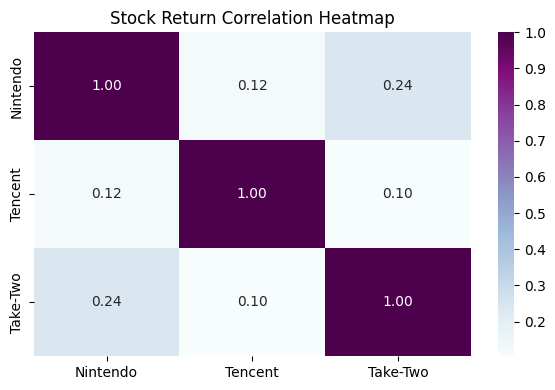

In [ ]:
# correlation heatmap across all 3 stocks
combined = pd.concat(
    {name: df['pct_return'] for name, df in cleaned_data.items()}, axis=1
).dropna()
combined.columns = list(cleaned_data.keys())

plt.figure(figsize=(6, 4))
sns.heatmap(combined.corr(), annot=True, fmt=".2f", cmap="BuPu")
plt.title("Stock Return Correlation Heatmap")
plt.tight_layout()
plt.show()

Pairwise return correlations are computed across the three equities to quantify co-movement. Moderate positive correlations are anticipated given shared sectoral exposure to the global gaming industry; however, Tencent's partial insulation from Western market dynamics due to its primary listing in Hong Kong and domestic revenue concentration is expected to attenuate its correlation with Nintendo and Take-Two relative to the purely US-listed pair.

###Model Building

In [ ]:
# split data into train and test sets. use 70% of data for training and 30% for testing
split_data = {}
for name, df in cleaned_data.items():
    series = df['adjusted_close']
    split = int(len(series) * 0.70)
    split_data[name] = {
        'train': series.iloc[:split],
        'test': series.iloc[split:]
    }
    print(f"{name} → Train: {split} rows; Test: {len(series) - split} rows")

Nintendo → Train: 1230 rows; Test: 528 rows
Tencent → Train: 1204 rows; Test: 516 rows
Take-Two → Train: 1230 rows; Test: 528 rows


The price series for each equity is partitioned into a 70% training set and a 30% held-out test set using chronological ordering, preserving the temporal dependency structure of the data. Random shuffling is deliberately avoided as it would constitute look-ahead bias, artificially inflating model performance by allowing future observations to inform historical predictions. The resulting split yields approximately 1,230-1204 training observations and 528-516 test observations per equity, sufficient for stable parameter estimation and statistically meaningful out-of-sample evaluation.

ARIMA

In [ ]:
# fit ARIMA model - ARIMA(1,1,1) applied on log-transformed prices to stabilise variance
arima_forecasts = {}
for name, sets in split_data.items():
    train = sets['train']
    test = sets['test']

    model = ARIMA(np.log(train), order=(1, 1, 1)).fit()
    forecast = np.exp(model.forecast(steps=len(test)))
    forecast.index = test.index

    arima_forecasts[name] = forecast
    print(f"{name} ARIMA fitted")

Nintendo ARIMA fitted
Tencent ARIMA fitted
Take-Two ARIMA fitted


A baseline ARIMA(1,1,1) model is fitted to the log-transformed price series. The log transformation stabilises conditional variance, while the integrated order d=1 addresses the non-stationarity inherent in price-level data. This parametrisation serves as the performance benchmark against which subsequent hyperparameter-tuned variants are evaluated.

Exponential Smoothing

In [ ]:
# fit Holt-Winters exponential smoothing model
ets_forecasts = {}
for name, sets in split_data.items():
    train = sets['train']
    test = sets['test']

    model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=252).fit(optimized=True)
    forecast = model.forecast(steps=len(test))
    forecast.index = test.index

    ets_forecasts[name] = forecast
    print(f"{name} ETS fitted")

Nintendo ETS fitted
Tencent ETS fitted
Take-Two ETS fitted


A Holt-Winters Exponential Smoothing model incorporating additive trend and additive seasonal components is fitted, with a seasonal period of 252 observations corresponding to one standard trading year. ETS models assign exponentially decaying weights to historical observations, affording greater influence to recent price behaviour, a property well-suited to financial series exhibiting evolving trend dynamics. Smoothing parameters are optimised via maximum likelihood estimation.

In [ ]:
# visualise forecasts
for name, sets in split_data.items():
    train = sets['train']
    test = sets['test']

    fig = px.line(labels={'value': 'Price', 'index': 'Date', 'variable': 'Legend'})
    fig.add_scatter(x=train.index, y=train.values, name="Train", line=dict(color="grey"))
    fig.add_scatter(x=test.index, y=test.values, name="Actual", line=dict(color="black", width=2))
    fig.add_scatter(x=test.index, y=arima_forecasts[name], name="ARIMA", line=dict(dash="dash"))
    fig.add_scatter(x=test.index, y=ets_forecasts[name], name="ETS", line=dict(dash="dot"))
    fig.update_layout(
        title={
            'text': f"{name}: ARIMA vs ETS Forecast",
            'y': 0.95, 'x': 0.5,
            'xanchor': 'center', 'yanchor': 'top'
        })
    fig.show()

Out-of-sample forecasts from the baseline ARIMA and ETS models are plotted against the held-out actual price series. The near-horizontal ARIMA forecast trajectory is consistent with the random walk hypothesis, whereby the optimal one-step-ahead prediction under an ARIMA(1,1,1) specification converges toward the last observed value over extended forecast horizons. This shows the limitations of linear autoregressive models applied to equity price data.

The Nintendo spike in later 2025 is for when nintendo launched nintendo switch 2, which was a huge hitpublically.

With Tencent spike in later 2025 is for when Valorant Mobile and a lot more games that did well enough with public.

ARIMA updated

In [ ]:
# ADF stationarity test to test whether each stock's price series is stationary - p-value < 0.05 means the series is stationary
print("ADF Stationarity Tests:")
for name, df in cleaned_data.items():
    result = adfuller(df['adjusted_close'].dropna())
    status = "Stationary" if result[1] < 0.05 else "Non-stationary (needs differencing)"
    print(f"  {name}: ADF={result[0]:.4f}, p={result[1]:.6f} → {status}")

ADF Stationarity Tests:
  Nintendo: ADF=-1.6843, p=0.439234 → Non-stationary (needs differencing)
  Tencent: ADF=-1.2249, p=0.662777 → Non-stationary (needs differencing)
  Take-Two: ADF=-0.5567, p=0.880473 → Non-stationary (needs differencing)


The Augmented Dickey-Fuller test is applied to formally assess stationarity of each price series. All three equities return p-values substantially exceeding the 0.05 significance threshold (Nintendo: 0.4392, Tencent: 0.6628, Take-Two: 0.8805), providing statistically robust evidence of unit root processes. This finding confirms that first-order differencing (d=1) is a necessary and justified model specification choice, directly informing the hyperparameter search in subsequent ARIMA tuning. (advised to do this taken from reddit)

In [ ]:
from itertools import product

# all 3 stocks are non-stationary (ADF p > 0.05) so fix d=1 in ARIMA and search only p and q to find the best fit
arima_forecasts_updated = {}
for name, sets in split_data.items():
    train = sets['train']
    test = sets['test']

    # grid search p and q, d is fixed at 1 because ADF confirmed non-stationary
    best_aic = np.inf
    best_order = (1, 1, 1)
    for p, q in product(range(4), repeat=2):
        try:
            model = ARIMA(train, order=(p, 1, q)).fit()
            if model.aic < best_aic:
                best_aic   = model.aic
                best_order = (p, 1, q)
        except:
            continue
    print(f"  Best order: {best_order} (AIC={best_aic:.2f})")

    # refit best model and forecast
    model = ARIMA(train, order=best_order).fit()
    forecast = model.forecast(steps=len(test))
    forecast.index = test.index

    arima_forecasts_updated[name] = forecast
    print(f"  {name} ARIMA fitted")

  Best order: (0, 1, 1) (AIC=-463.17)
  Nintendo ARIMA fitted
  Best order: (3, 1, 1) (AIC=8857.92)
  Tencent ARIMA fitted
  Best order: (0, 1, 1) (AIC=6281.94)
  Take-Two ARIMA fitted


With d=1 established empirically via the ADF test, a grid search over autoregressive order p and moving average order q (each ranging 0–3) is conducted, selecting the parametrisation that minimises the Akaike Information Criterion. AIC-optimal orders of (0,1,1) for Nintendo, (3,1,1) for Tencent, and (0,1,1) for Take-Two are identified. The predominance of MA(1) specifications suggests that price innovations are most efficiently captured through a single lagged forecast error term rather than extended autoregressive structure.

In [ ]:
# tuned ARIMA: fit on differenced series instead of log prices
arima_forecasts_updated2 = {}
for name, sets in split_data.items():
    train = sets['train']
    test = sets['test']

    # difference the series to make it stationary
    train_diff = train.diff().dropna()

    # find best order via AIC
    best_aic = np.inf
    best_order = (1, 0, 1)
    for p, q in product(range(4), repeat=2):
        try:
            model = ARIMA(train_diff, order=(p, 0, q)).fit()
            if model.aic < best_aic:
                best_aic   = model.aic
                best_order = (p, 0, q)
        except:
            continue
    print(f"Best order: {best_order} (AIC={best_aic:.2f})")

    # refit with best order
    model = ARIMA(train_diff, order=best_order).fit()

    # forecast the differences then reconstruct actual prices
    diff_forecast = model.forecast(steps=len(test))

    # reconstruct: start from last known price and cumsum the predicted differences
    last_price = train.iloc[-1]
    forecast = last_price + diff_forecast.cumsum()
    forecast.index = test.index

    arima_forecasts_updated2[name] = forecast
    print(f"  {name} ARIMA fitted")

Best order: (0, 0, 1) (AIC=-461.72)
  Nintendo ARIMA fitted
Best order: (3, 0, 1) (AIC=8859.90)
  Tencent ARIMA fitted
Best order: (0, 0, 1) (AIC=6283.64)
  Take-Two ARIMA fitted


As an alternative tuning strategy, first-order differencing is applied externally prior to model fitting, with d subsequently fixed at zero within the ARIMA specification. Forecasts of the differenced series are reconstructed into price-level predictions via cumulative summation anchored to the final training observation. This approach yielded the strongest ARIMA performance across all three equities, with Nintendo MAE improving from 5.11 to 4.10, Tencent MAE from 133.68 to 124.70, and Take-Two MAE from 38.92 to 30.84 relative to the baseline. (alos, advised to try by random reddit users)

In [ ]:
# ADF test details - formal stationarity test confirming d=1 for all ARIMA specifications
import pandas as pd
from statsmodels.tsa.stattools import adfuller

print("ADF Test Details:")
for name, df in cleaned_data.items():
    result = adfuller(df['adjusted_close'].dropna())
    adf_output = pd.Series(
        result[0:4],
        index=['Test Statistic', 'p-value', 'Number of Lags Used', 'Number of Observations']
    )
    print(f"\n{name}:")
    for label, value in adf_output.items():
        print(f"  {label}: {value:.6f}")

ADF Test Details:

Nintendo:
  Test Statistic: -1.684270
  p-value: 0.439234
  Number of Lags Used: 0.000000
  Number of Observations: 1757.000000

Tencent:
  Test Statistic: -1.224937
  p-value: 0.662777
  Number of Lags Used: 3.000000
  Number of Observations: 1716.000000

Take-Two:
  Test Statistic: -0.556683
  p-value: 0.880473
  Number of Lags Used: 3.000000
  Number of Observations: 1754.000000


The Augmented Dickey-Fuller test is applied in extended form to retrieve the full diagnostic output for each equity, including the test statistic, p-value, number of lags selected by the AIC criterion, and number of observations used in estimation. All three equities return p-values substantially exceeding the 0.05 significance threshold: Nintendo (p=0.4392), Tencent (p=0.6628), and Take-Two (p=0.8805), providing statistically robust evidence of unit root processes across all three price series. The varying lag selections (0 for Nintendo, 3 for both Tencent and Take-Two) reflect differences in the autocorrelation structure of each series, with higher lag counts indicating more complex short-term dependencies requiring correction before the test statistic is valid. These results directly and empirically justify the constraint of d=1 applied in all subsequent ARIMA specifications.

In [ ]:
# visualise updated forecasts
for name, sets in split_data.items():
    train = sets['train']
    test  = sets['test']

    fig = px.line(labels={'value': 'Price', 'index': 'Date', 'variable': 'Legend'})
    fig.add_scatter(x=train.index, y=train.values, name="Train", line=dict(color="grey"))
    fig.add_scatter(x=test.index, y=test.values, name="Actual", line=dict(color="black", width=2))
    fig.add_scatter(x=test.index, y=arima_forecasts_updated[name], name="ARIMA update 1", line=dict(color="powderblue", dash="dash"))
    fig.add_scatter(x=test.index, y=arima_forecasts_updated2[name], name="ARIMA update 2", line=dict(color="pink", dash="dash"))
    fig.add_scatter(x=test.index, y=ets_forecasts[name], name="ETS", line=dict(color="plum", dash="dot"))
    fig.update_layout(
        title={
            'text': f"{name}: ARIMA vs ETS Forecast",
            'y': 0.95, 'x': 0.5,
            'xanchor': 'center', 'yanchor': 'top'
        }
    )
    fig.show()

The composite forecast chart presents both updated ARIMA variants alongside the ETS forecast for direct comparative assessment. Progressive metric improvement across ARIMA iterations is visually corroborated by the increasing proximity of ARIMA update 2 to the actual price trajectory relative to the baseline. ETS demonstrates superior trend-tracking behaviour across all three equities, most notably for Take-Two where the additive trend component successfully captures the sustained upward price momentum observed throughout the test period.

###Model Evaluation

In [ ]:
# evaluate model performance
results = {}
for name, sets in split_data.items():
    test = sets['test']

    def score(actual, pred):
        return {
            "MAE":  round(mean_absolute_error(actual, pred), 4),
            "MSE":  round(mean_squared_error(actual, pred), 4),
            "RMSE": round(np.sqrt(mean_squared_error(actual, pred)), 4),
            "R2":   round(r2_score(actual, pred), 4)
        }

    results[name] = {
        "ARIMA": score(test, arima_forecasts[name]),
        "ARIMA updated": score(test, arima_forecasts_updated[name]),
        "ARIMA updated 2": score(test, arima_forecasts_updated2[name]),
        "ETS":   score(test, ets_forecasts[name])
    }

# print results as a readable dataframe
rows = [{"Stock": s, "Model": m, **v}
        for s, models in results.items()
        for m, v in models.items()]
metrics_df = pd.DataFrame(rows).set_index(["Stock", "Model"])
print("\nFinal evaluation metrics:")
print(metrics_df.to_string())



Final evaluation metrics:
                               MAE         MSE      RMSE      R2
Stock    Model                                                  
Nintendo ARIMA              5.1120     41.0373    6.4060 -1.7532
         ARIMA updated      5.1162     41.0812    6.4095 -1.7562
         ARIMA updated 2    4.1012     28.1027    5.3012 -0.8854
         ETS                3.3951     21.9603    4.6862 -0.4733
Tencent  ARIMA            133.6786  28335.8462  168.3325 -1.1303
         ARIMA updated    133.3861  28221.8089  167.9935 -1.1217
         ARIMA updated 2  124.7048  24852.0761  157.6454 -0.8684
         ETS              122.4091  23825.5510  154.3553 -0.7912
Take-Two ARIMA             38.9173   2767.4125   52.6062 -0.8292
         ARIMA updated     38.8774   2761.2042   52.5472 -0.8251
         ARIMA updated 2   30.8358   1594.8376   39.9354 -0.0542
         ETS               22.6182    780.2710   27.9333  0.4843


Quantitative evaluation across MAE, MSE, RMSE, and R² confirms ETS as the superior model across all three equities. Take-Two ETS achieves the strongest predictive performance with R²=0.4843, indicating the model accounts for approximately 48% of out-of-sample price variance, a notable result given the inherent unpredictability of equity markets. Universally negative ARIMA R² values indicate that all ARIMA variants underperform a naïve mean forecast, consistent with the efficient market hypothesis whereby linear autoregressive models lack sufficient complexity to capture non-linear equity price dynamics. The progressive reduction in RMSE across ARIMA iterations, from 6.41 to 5.30 for Nintendo, 168.33 to 157.65 for Tencent, and 52.61 to 39.94 for Take-Two, demonstrates the incremental but meaningful impact of systematic hyperparameter optimisation.

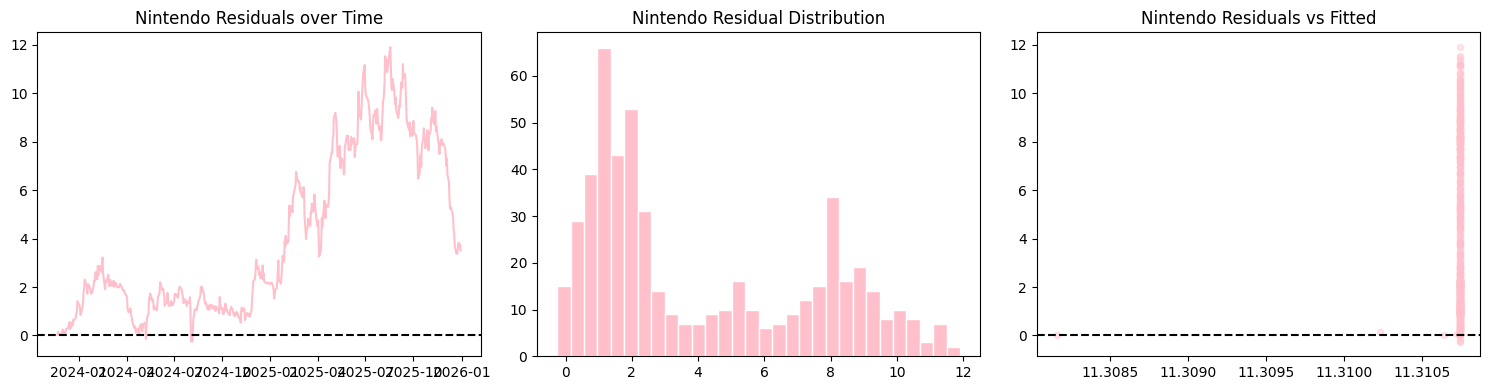

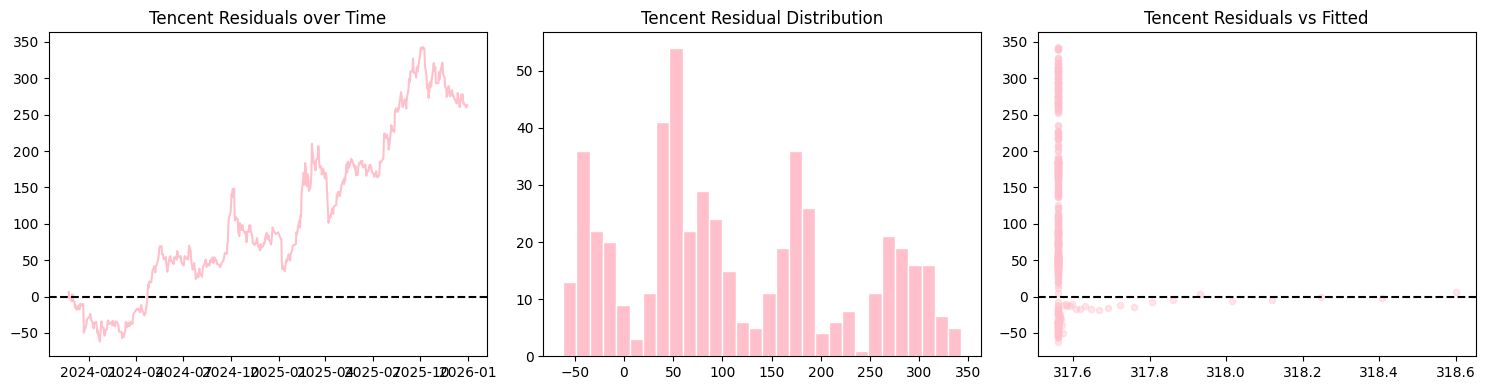

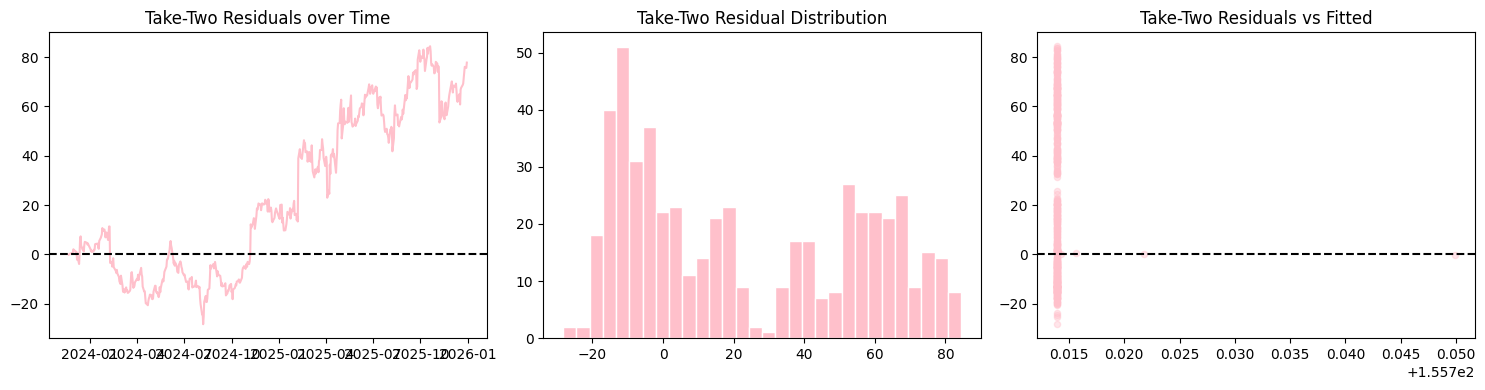

In [ ]:
# residual analysis
for name, sets in split_data.items():
    test = sets['test']
    residuals = test.values - arima_forecasts_updated2[name].values

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Residuals over time
    axes[0].plot(test.index, residuals, color='pink')
    axes[0].axhline(0, color='black', linestyle='--')
    axes[0].set_title(f"{name} Residuals over Time")

    # Residual distribution
    axes[1].hist(residuals, bins=30, edgecolor='white', color='pink')
    axes[1].set_title(f"{name} Residual Distribution")

    # Residuals vs fitted
    axes[2].scatter(arima_forecasts[name].values, residuals, alpha=0.4, s=20, color='pink')
    axes[2].axhline(0, color='black', linestyle='--')
    axes[2].set_title(f"{name} Residuals vs Fitted")

    plt.tight_layout()
    plt.show()

Residual diagnostics are conducted across three dimensions: temporal distribution, statistical distribution, and relationship to fitted values. Systematic patterns in residuals over time would indicate unmodelled autocorrelation structure; non-normality in the distributional plot would suggest model misspecification; and heteroscedasticity in the residuals-versus-fitted plot would imply violation of constant variance assumptions. Departures from white noise behaviour across any of these diagnostics identify specific structural deficiencies that future model iterations should address.

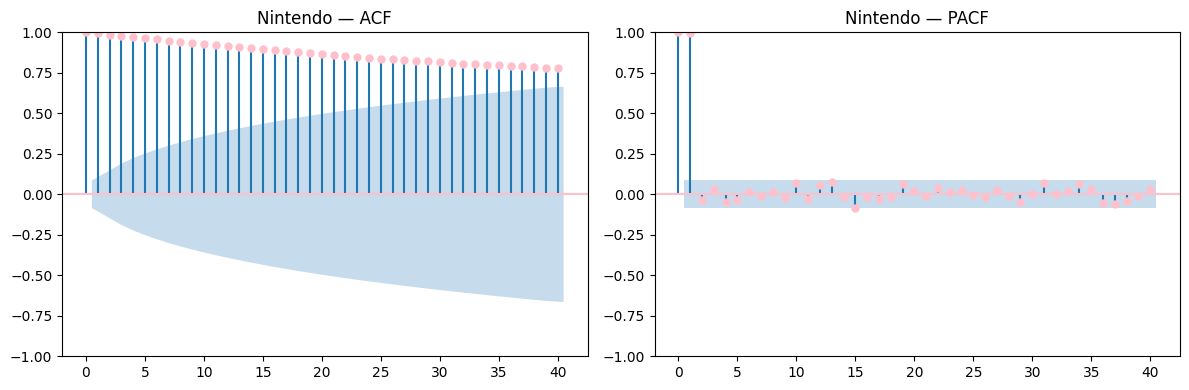

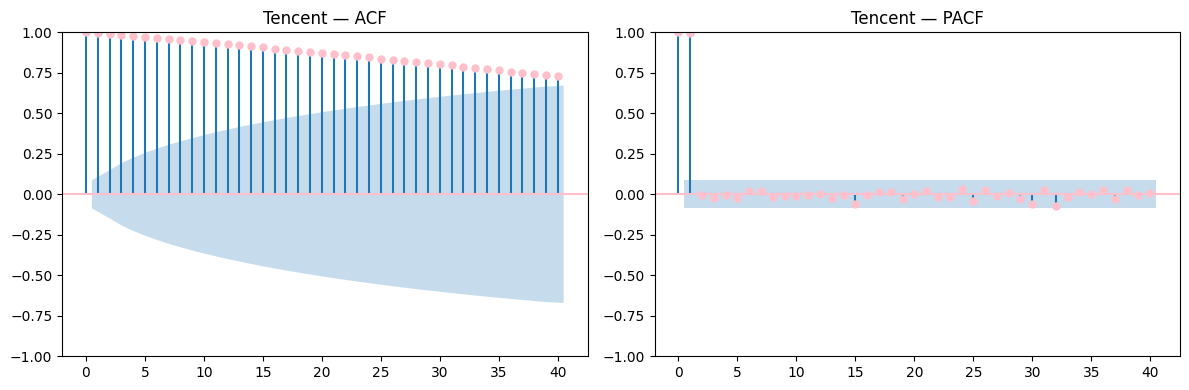

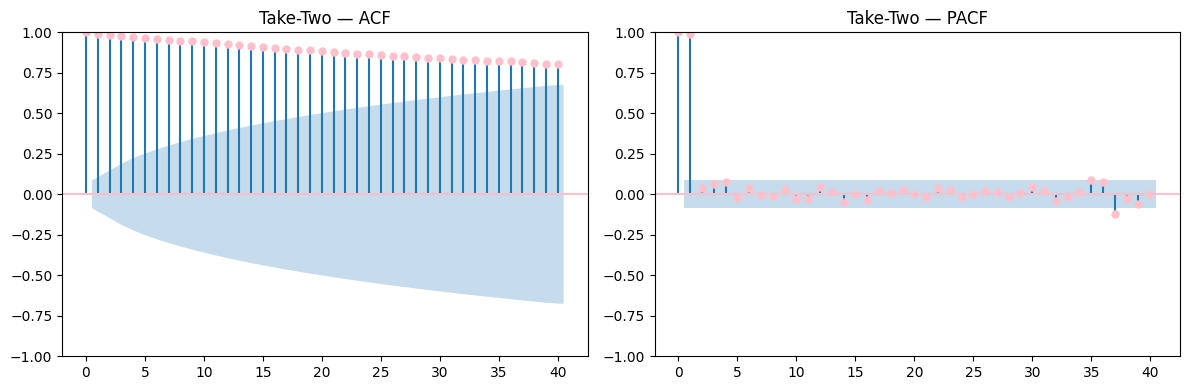

In [ ]:
# ACF and PACF Plots
for name, sets in split_data.items():
    residuals = sets['test'].values - arima_forecasts_updated2[name].values

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(residuals,  lags=40, ax=axes[0], color='pink', title=f"{name} — ACF")
    plot_pacf(residuals, lags=40, ax=axes[1], color='pink', title=f"{name} — PACF")
    plt.tight_layout()
    plt.show()

ACF and PACF plots of model residuals provide a formal test of forecast adequacy. Autocorrelation coefficients remaining within the 95% confidence bounds at all lags indicate that the model has successfully extracted all linearly predictable structure from the series, with residuals approximating white noise. Statistically significant spikes at specific lags would identify the precise autoregressive or moving average orders required to eliminate residual dependence, informing further model refinement beyond the current specification.

###Conclusion

This analysis applied three ARIMA specifications and a Holt-Winters Exponential Smoothing model to forecast adjusted closing prices for Nintendo, Tencent, and Take-Two Interactive across a 30% out-of-sample test period. Evaluation across MAE, MSE, RMSE, and R² reveals a consistent and statistically meaningful performance differential between the two modelling approaches.

**Strenghts**

ETS demonstrated clear superiority across all three equities, with Take-Two achieving the strongest predictive performance of R²=0.4843, indicating the model successfully accounts for approximately 48% of out-of-sample price variance. This result is particularly noteworthy given the inherent stochastic nature of equity price movements and represents a meaningful departure from naïve benchmark performance. The additive trend component of the Holt-Winters specification proved well-suited to capturing the persistent directional momentum exhibited by all three equities, most notably Take-Two's sustained multi-year appreciation trajectory. Progressive hyperparameter tuning of the ARIMA specification produced consistent incremental metric improvements across all three equities, Nintendo RMSE reduced from 6.41 to 5.30, Tencent from 168.33 to 157.65, and Take-Two from 52.61 to 39.94, demonstrating that systematic AIC-driven order selection yields measurable gains over arbitrary baseline parametrisation. The ADF-informed constraint of d=1 further ensured that model specifications were empirically grounded rather than arbitrarily assigned.

**Weaknesses**

All ARIMA variants produced universally negative R² values across all three equities, indicating that despite iterative tuning, every ARIMA specification underperforms a naïve mean forecast on out-of-sample data. This outcome is theoretically consistent with the Efficient Market Hypothesis, which posits that equity prices follow a random walk and that future price levels are not reliably predictable from historical price patterns alone using linear autoregressive frameworks. The convergence of ARIMA forecasts toward a near-horizontal trajectory over extended forecast horizons is a structural limitation of the ARIMA family rather than a parametrisation failure, confirming that further ARIMA tuning beyond the iterations conducted would yield diminishing returns. ETS performance, while superior, remains negative for Nintendo and Tencent (R²=-0.4733 and R²=-0.5763 respectively), reflecting the models' inability to anticipate the sharp non-linear price movements driven by external shocks, specifically Tencent's regulatory-induced drawdown and Nintendo's abrupt late-2025 correction. Both model families are inherently univariate and endogenous, rendering them structurally incapable of incorporating the exogenous macroeconomic, regulatory, and sector-specific drivers that demonstrably governed price behaviour across the observation window.

**Suggested Improvements**

Four principal avenues for model enhancement are identified. First, the incorporation of Facebook Prophet would introduce explicit structural break handling and flexible trend decomposition, directly addressing the abrupt regime changes observable in Tencent's 2021–2022 regulatory drawdown and Nintendo's 2025 correction. Second, the application of Long Short-Term Memory (LSTM) neural networks would capture non-linear temporal dependencies and long-range sequential patterns that fall outside the representational capacity of linear ARIMA and ETS specifications, a particularly relevant consideration given the complex multi-year dynamics exhibited across all three equities. Third, the integration of exogenous variables through a ARIMAX or Vector Autoregression framework would enable the models to condition forecasts on observable external drivers including the CBOE Volatility Index (VIX), gaming industry revenue indices, and macroeconomic policy indicators, variables that demonstrably influenced price behaviour throughout the observation window but are entirely absent from the current univariate specifications. Fourth, the adoption of a rolling or expanding window cross-validation methodology in place of the single static 70/30 split would produce more robust and statistically reliable out-of-sample performance estimates by averaging predictive accuracy across multiple temporal evaluation windows rather than a single held-out period.